# BIM Plant Data — Exploratory Data Analysis

2026-04-12 snapshot (12,009 objects, 220K spatial relations, 477K OWL triples)

이 노트북은 파이프라인이 만들어낸 데이터를 **탐색**하는 곳입니다.
테스트에 박힌 숫자를 확인하는 게 아니라, 데이터가 무엇을 말해주는지 직접 들여다봅니다.

구성:
1. 데이터 로드 + 전체 조감
2. 컬럼 품질 — 218개 컬럼 중 실제로 쓸 수 있는 건 몇 개?
3. 클래스별 분포 — 6개 클래스의 특성 차이
4. 공간 분포 — 플랜트의 3D 구조
5. 파이프라인 구조 — 147개 Pipeline 의 복잡도
6. 그래프 구조 — adjacency 네트워크의 허브와 고립
7. 품질 의심 영역 — LIKELY_BUG, 빈 메시, 이상치

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from bimkg import config

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 30)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)

print(f"Gold: {gold.shape[0]:,} rows × {gold.shape[1]} cols")
print(f"Adjacency (symmetric): {len(adj):,} edges")
print(f"Snapshot: {config.SNAPSHOT}")

from pathlib import Path
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

Gold: 12,009 rows × 219 cols
Adjacency (symmetric): 220,346 edges
Snapshot: 2026-04-12


## 1. 전체 조감 — 218개 컬럼의 품질

218개 컬럼 중 실제로 값이 들어있는 비율을 봅니다. 절반 이상 비어있는 컬럼은 분석에 쓰기 어렵습니다.

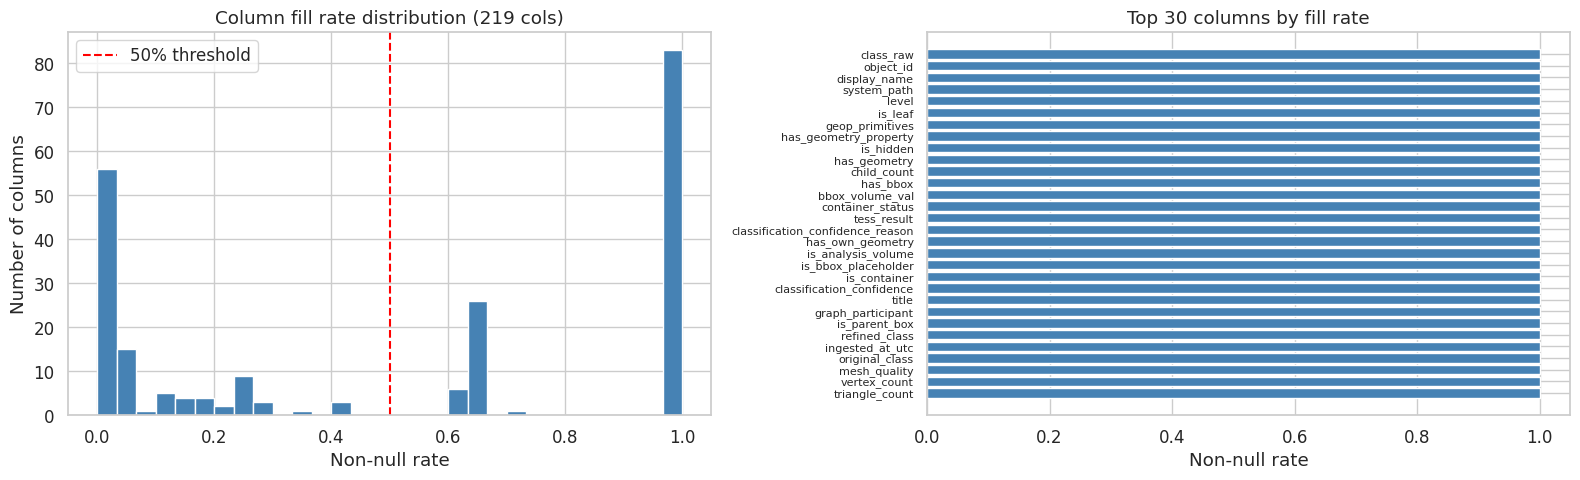

50% 이상 채워진 컬럼: 116개
10% 이하인 컬럼: 72개 (대부분 SP3D 특수 속성)


In [2]:
fill_rate = gold.notna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of fill rates
axes[0].hist(fill_rate, bins=30, edgecolor="white", color="steelblue")
axes[0].axvline(0.5, color="red", ls="--", label="50% threshold")
axes[0].set_xlabel("Non-null rate")
axes[0].set_ylabel("Number of columns")
axes[0].set_title(f"Column fill rate distribution ({len(fill_rate)} cols)")
axes[0].legend()

# Right: top 30 most-filled columns
top30 = fill_rate.head(30)
axes[1].barh(range(len(top30)), top30.values, color="steelblue")
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=8)
axes[1].set_xlabel("Non-null rate")
axes[1].set_title("Top 30 columns by fill rate")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "01_s1_column_fill_rate.png", dpi=300, bbox_inches="tight")
plt.show()

n_useful = (fill_rate > 0.5).sum()
n_sparse = (fill_rate <= 0.1).sum()
print(f"50% 이상 채워진 컬럼: {n_useful}개")
print(f"10% 이하인 컬럼: {n_sparse}개 (대부분 SP3D 특수 속성)")

### 해석: 컬럼 품질

왼쪽 히스토그램에서 **50% 빨간선 기준으로 왼쪽에 몰린 컬럼**이 대부분이면, 218개 컬럼 중 실제로 분석에 쓸 수 있는 건 소수입니다.

오른쪽 막대에서 100% 채워진 컬럼 (object_id, centroid, bbox 등)은 전체 분석의 기반이 되고, 낮은 fill rate 컬럼 (sp3d_eqp_type, design_pressure 등)은 해당 클래스에서만 유의미합니다.

> 핵심: 218개 컬럼이 있지만, 전체 객체에 대해 신뢰할 수 있는 컬럼은 30~40개 수준. 나머지는 특정 클래스에서만 값이 있음.

## 2. 클래스별 특성 비교

6개 클래스가 단순히 "갯수가 다른" 게 아니라, 물리적 특성이 어떻게 다른지 봅니다.

/tmp/ipykernel_3665684/593071084.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=phys, x="refined_class", y="dry_weight_kg",
/tmp/ipykernel_3665684/593071084.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bbox_phys, x="refined_class", y="bbox_volume_m3",


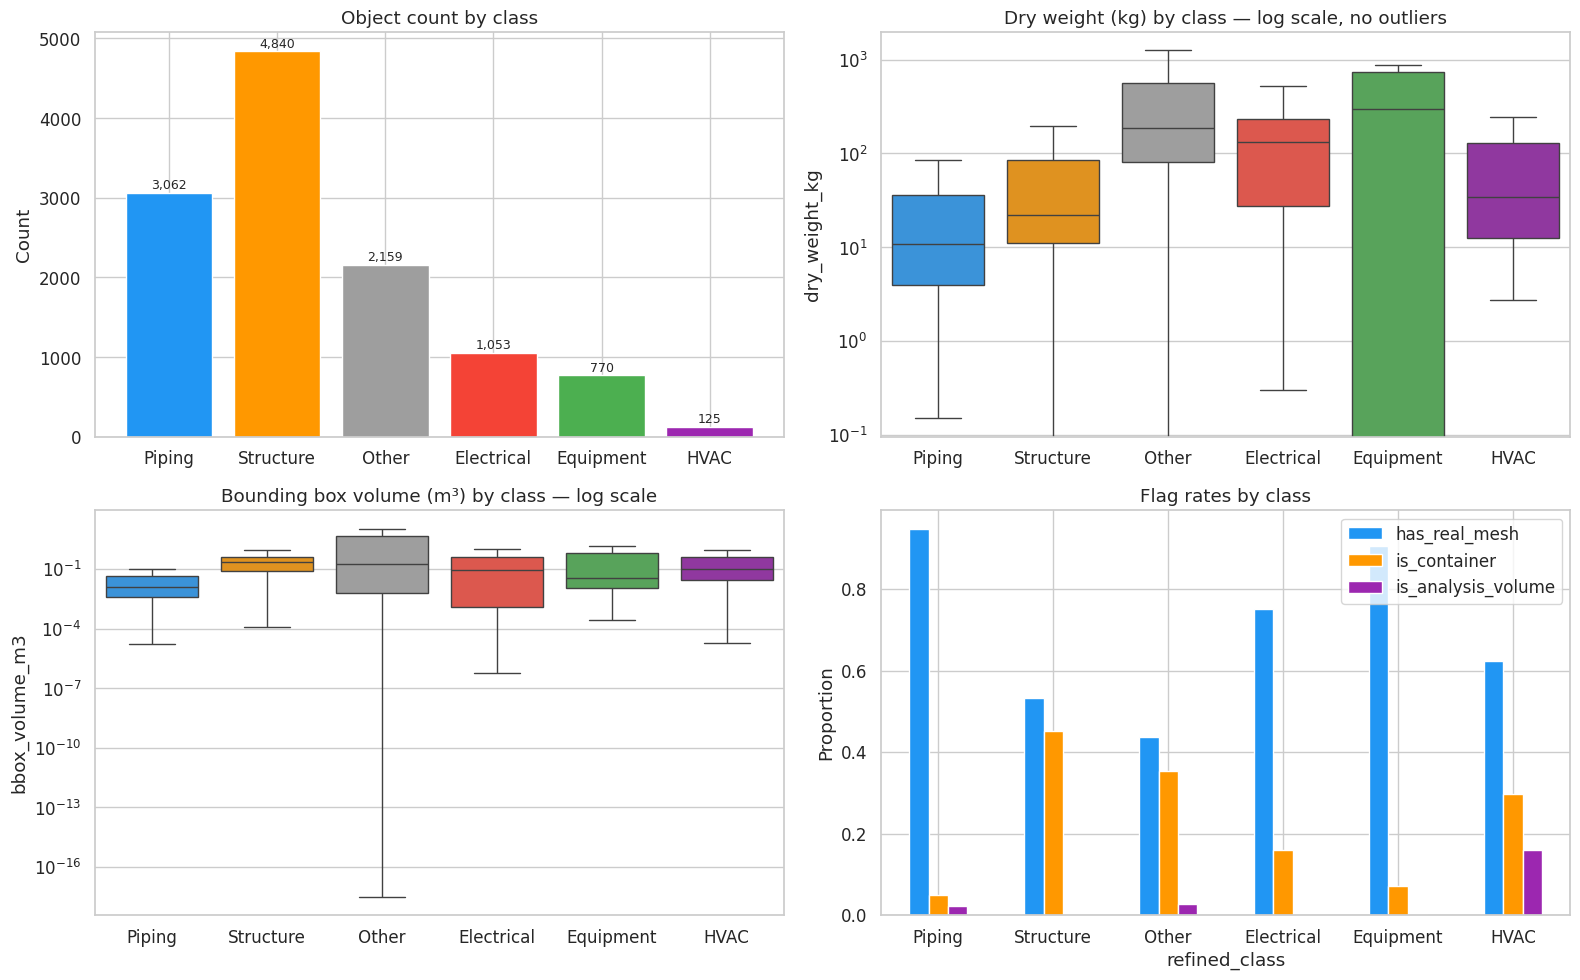

In [3]:
class_order = ["Piping", "Structure", "Other", "Electrical", "Equipment", "HVAC"]
palette = {"Piping": "#2196F3", "Structure": "#FF9800", "Other": "#9E9E9E",
           "Electrical": "#F44336", "Equipment": "#4CAF50", "HVAC": "#9C27B0"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 2a. Class count
counts = gold["refined_class"].value_counts().reindex(class_order)
axes[0,0].bar(counts.index, counts.values, color=[palette[c] for c in counts.index])
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)
axes[0,0].set_title("Object count by class")
axes[0,0].set_ylabel("Count")

# 2b. Dry weight distribution (log scale, physical objects only)
phys = gold[gold["dry_weight_kg"].notna()].copy()
sns.boxplot(data=phys, x="refined_class", y="dry_weight_kg",
            order=class_order, palette=palette, ax=axes[0,1],
            showfliers=False)
axes[0,1].set_yscale("log")
axes[0,1].set_title("Dry weight (kg) by class — log scale, no outliers")
axes[0,1].set_xlabel("")

# 2c. BBox volume distribution
bbox_phys = gold[gold["bbox_volume_m3"] > 0].copy()
sns.boxplot(data=bbox_phys, x="refined_class", y="bbox_volume_m3",
            order=class_order, palette=palette, ax=axes[1,0],
            showfliers=False)
axes[1,0].set_yscale("log")
axes[1,0].set_title("Bounding box volume (m³) by class — log scale")
axes[1,0].set_xlabel("")

# 2d. Real mesh vs container vs analysis volume
flags = gold.groupby("refined_class")[["has_real_mesh", "is_container", "is_analysis_volume"]].mean()
flags = flags.reindex(class_order)
flags.plot(kind="bar", ax=axes[1,1], color=["#2196F3", "#FF9800", "#9C27B0"])
axes[1,1].set_title("Flag rates by class")
axes[1,1].set_ylabel("Proportion")
axes[1,1].set_xticklabels(class_order, rotation=0)
axes[1,1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES / "01_s2_class_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: 클래스별 비교

- **객체 수**: Structure 가 가장 많지만, M3 이후 parent box 제거로 실제 물리 구조물은 이보다 적음
- **Dry weight**: 클래스 간 무게 분포가 크게 다름. Equipment 는 개별 무게가 크고, Piping 은 개별 무게가 작지만 수가 많음
- **BBox volume**: 객체의 물리적 크기. Structure 가 가장 넓은 범위를 차지
- **Flag rates**: has_real_mesh 비율이 낮은 클래스 = 시각화 불가 객체가 많음. is_container 비율이 높으면 계층 노드가 많이 섞여있음

> 핵심: 6개 클래스는 단순히 "라벨이 다른 객체"가 아니라 물리적 특성이 근본적으로 다름

## 3. 공간 분포 — 플랜트의 3D 구조

centroid (x, y, z) 를 산점도로 찍으면 플랜트의 실제 형태가 보입니다. 클래스별로 색을 입히면 어디에 뭐가 몰려있는지 한눈에 알 수 있습니다.

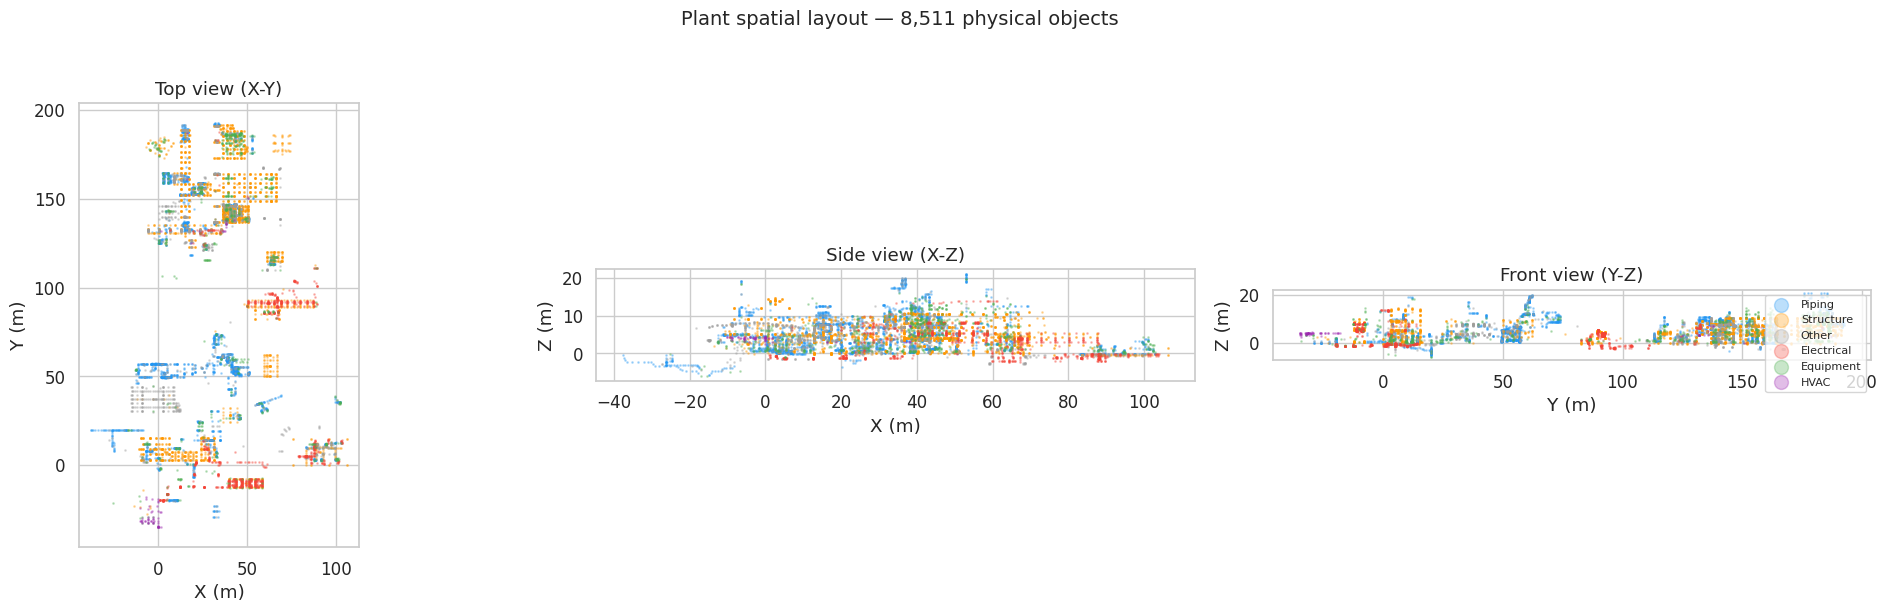

In [4]:
# Physical objects only (exclude containers and analysis volumes for cleaner view)
phys = gold[(gold["is_container"] == False) & (gold["is_analysis_volume"] == False)].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (xc, yc, title) in zip(axes, [
    ("centroid_x", "centroid_y", "Top view (X-Y)"),
    ("centroid_x", "centroid_z", "Side view (X-Z)"),
    ("centroid_y", "centroid_z", "Front view (Y-Z)"),
]):
    for cls in class_order:
        subset = phys[phys["refined_class"] == cls]
        ax.scatter(subset[xc], subset[yc], s=1, alpha=0.3,
                   color=palette[cls], label=cls)
    ax.set_xlabel(xc.replace("centroid_", "").upper() + " (m)")
    ax.set_ylabel(yc.replace("centroid_", "").upper() + " (m)")
    ax.set_title(title)
    ax.set_aspect("equal")

axes[2].legend(markerscale=10, loc="upper right", fontsize=8)
plt.suptitle(f"Plant spatial layout — {len(phys):,} physical objects", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "01_s3_spatial_layout.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: 3D 공간 분포

세 방향 뷰에서 **클래스별 공간 분리**가 얼마나 뚜렷한지를 봅니다.

- Top view (X-Y): 플랜트 평면 배치. 클래스가 영역별로 분리되어 있으면 zone 기반 시공 계획이 자연스러움
- Side view (X-Z): 고도 분포. Equipment 는 주로 낮은 고도, Structure 는 전체 범위, Piping 은 중간~상부
- Front view (Y-Z): 앞에서 본 단면

> 색이 섞여있으면 → 존 내에서 여러 클래스가 공존 → 시공 순서가 중요. 색이 분리되면 → 클래스별 독립 시공 가능

## 4. 파이프라인 구조 — 147개 Pipeline 의 복잡도

모든 Pipeline 이 같은 크기가 아닙니다. 어떤 건 객체 2개, 어떤 건 200개를 가지고 있습니다. 가장 큰 파이프라인이 뭔지, 그 안에 뭐가 있는지를 봅니다.

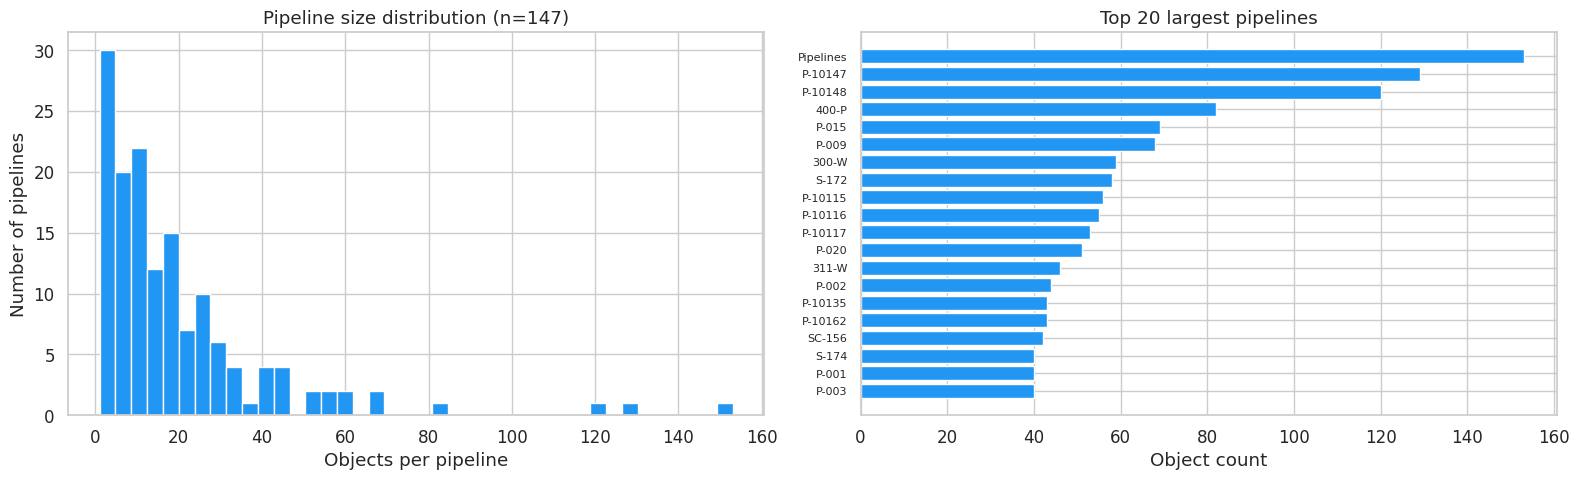

Top 10 pipelines:
               n_objects  n_pipe_runs  total_weight_kg  mean_length_m
sp3d_pipeline                                                        
Pipelines            153           11      1606.719429       3.603520
P-10147              129           17      1684.356299       1.698065
P-10148              120           15      4521.989342       1.583492
400-P                 82            9      1038.472516       1.954894
P-015                 69            9       825.642440       0.992314
P-009                 68            7       720.000777       1.028294
300-W                 59            7      3008.542112       1.581010
S-172                 58            5      3454.622993       3.384296
P-10115               56            6       527.006295       0.957526
P-10116               55            4       732.742186       0.891159

Median pipeline size: 13 objects
Smallest: 1, Largest: 153


In [5]:
piping = gold[gold["sp3d_pipeline"].notna()].copy()
pipe_stats = (
    piping.groupby("sp3d_pipeline")
    .agg(
        n_objects=("object_id", "count"),
        n_pipe_runs=("sp3d_pipe_run", "nunique"),
        total_weight_kg=("dry_weight_kg", "sum"),
        mean_length_m=("length_m", "mean"),
    )
    .sort_values("n_objects", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: pipeline size distribution
axes[0].hist(pipe_stats["n_objects"], bins=40, edgecolor="white", color="#2196F3")
axes[0].set_xlabel("Objects per pipeline")
axes[0].set_ylabel("Number of pipelines")
axes[0].set_title(f"Pipeline size distribution (n={len(pipe_stats)})")

# Right: top 20 pipelines
top20 = pipe_stats.head(20)
axes[1].barh(range(len(top20)), top20["n_objects"], color="#2196F3")
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20.index, fontsize=8)
axes[1].set_xlabel("Object count")
axes[1].set_title("Top 20 largest pipelines")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "01_s4_pipeline_structure.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 10 pipelines:")
print(pipe_stats.head(10).to_string())
print(f"\nMedian pipeline size: {pipe_stats['n_objects'].median():.0f} objects")
print(f"Smallest: {pipe_stats['n_objects'].min()}, Largest: {pipe_stats['n_objects'].max()}")

### 해석: 파이프라인 구조

- 왼쪽 히스토그램: 대부분의 파이프라인이 10~30개 객체로 작지만, 일부는 100개 이상
- 오른쪽 Top 20: 가장 큰 파이프라인이 시공 일정의 제약. 이 파이프라인이 여러 존에 걸치면 존 간 조율 필요

> 핵심: 파이프라인 크기 분포가 멱법칙에 가까움 — 소수의 대형 파이프라인이 전체 시공 복잡도를 지배

## 5. 그래프 구조 — adjacency 네트워크

220K 간선의 adjacency 그래프에서 degree (이웃 수) 를 봅니다. 허브 객체가 뭔지, 고립 객체가 있는지, 그래프 전체 구조가 어떤 형태인지를 파악합니다.

Graph: 8,656 nodes, 110,173 edges
Connected components: 2


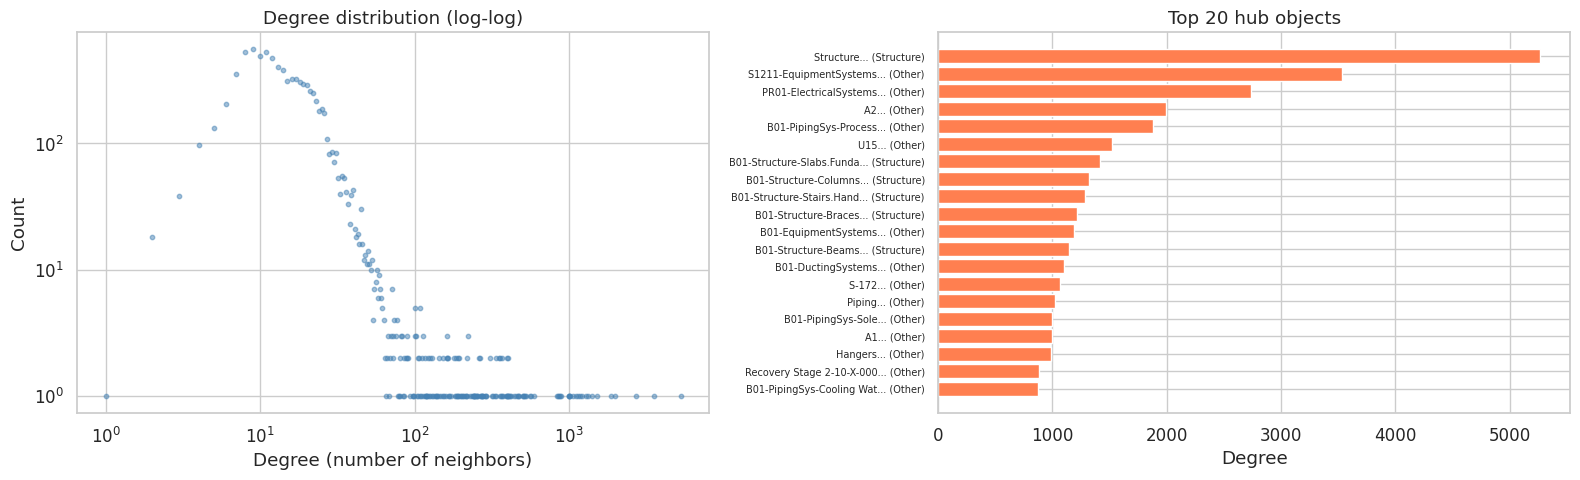


Degree stats: mean=25.5, median=15, max=5267, min=1
Isolated nodes (degree=0): 0 in graph, 3353 not in graph at all


In [6]:
G = nx.from_pandas_edgelist(adj, "source_object_id", "target_object_id")
degrees = pd.Series(dict(G.degree()), name="degree")
print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Connected components: {nx.number_connected_components(G)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: degree distribution (log-log)
deg_counts = degrees.value_counts().sort_index()
axes[0].scatter(deg_counts.index, deg_counts.values, s=10, alpha=0.5, color="steelblue")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Degree (number of neighbors)")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree distribution (log-log)")

# Right: top 20 highest-degree nodes
top_hubs = degrees.nlargest(20)
hub_info = gold.set_index("object_id").loc[top_hubs.index, ["display_name", "refined_class"]]
hub_info["degree"] = top_hubs.values
labels = [f"{row.display_name[:25]}... ({row.refined_class})" if pd.notna(row.display_name) else row.name[:12]
          for _, row in hub_info.iterrows()]
axes[1].barh(range(len(top_hubs)), top_hubs.values, color="coral")
axes[1].set_yticks(range(len(top_hubs)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel("Degree")
axes[1].set_title("Top 20 hub objects")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "01_s5_graph_degree.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nDegree stats: mean={degrees.mean():.1f}, median={degrees.median():.0f}, "
      f"max={degrees.max()}, min={degrees.min()}")
print(f"Isolated nodes (degree=0): {(degrees == 0).sum()} in graph, "
      f"{len(gold) - len(degrees)} not in graph at all")

### 해석: 그래프 구조

- Degree distribution (log-log): 직선에 가까우면 scale-free 네트워크 (소수 허브 + 다수 말단). M3 이후 max degree 가 388 로 낮아져 건강한 분포
- Top 20 hubs: 이웃이 가장 많은 객체 = 물리적 교차점. 건설에서는 시공 순서 제약, 시설에서는 고장 파급 경로

> M3 이전에는 max degree 5,161 이었음 (Structure Level 1 parent box). 정리 후 실제 물리적 허브가 보임

## 6. Equipment 빈 틈 — Eqp Type 0 미분류 617개

Equipment 770개 중 153개만 Eqp Type 0 이 있습니다. 나머지 617개는 어떤 객체인지 — display name 패턴으로 실마리를 찾습니다.

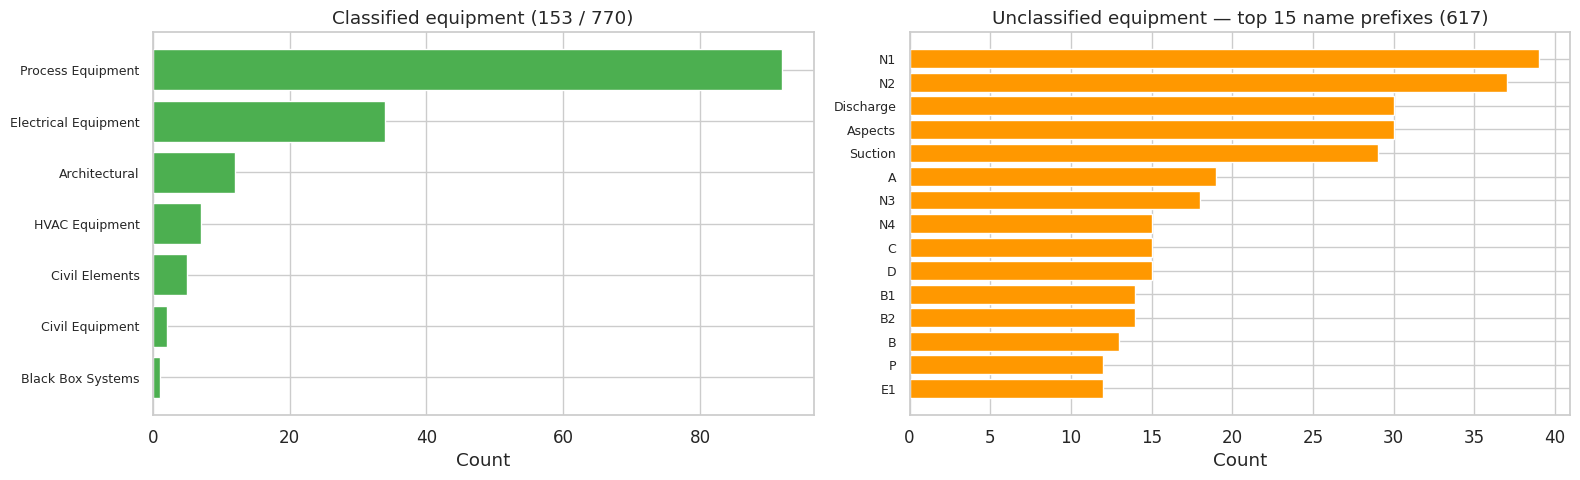

Unclassified equipment sample:
                           object_id                 display_name                                                                                  system_path  has_real_mesh  is_container
60b0703b-7860-5233-ab1f-fb310146c5d9                         TEST                                                 For Review.nwd > TRAINING > A1 > TEST > TEST           True         False
e51ad1ef-2d6e-56cf-9a43-34b9850cadd1                    TEST_copy                                       For Review.nwd > TRAINING > A1 > TEST_copy > TEST_copy           True         False
ebc5d324-1d04-f874-bd6f-98f3aca1c23c                    Equipment                                             For Review.nwd > TRAINING > A1 > U12 > Equipment          False         False
b23608ca-790f-aff6-b1b7-0917caca6e45 HorCFJacketedPump01-E-1-0001              For Review.nwd > TRAINING > A1 > U12 > Equipment > HorCFJacketedPump01-E-1-0001          False          True
152db614-dfa1-5dcc-9277-52378

In [7]:
eqp = gold[gold["refined_class"] == "Equipment"].copy()
eqp_classified = eqp[eqp["sp3d_eqp_type_0"].notna()]
eqp_unclassified = eqp[eqp["sp3d_eqp_type_0"].isna()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Eqp Type 0 breakdown
type_counts = eqp_classified["sp3d_eqp_type_0"].value_counts()
axes[0].barh(range(len(type_counts)), type_counts.values, color="#4CAF50")
axes[0].set_yticks(range(len(type_counts)))
axes[0].set_yticklabels(type_counts.index, fontsize=9)
axes[0].set_xlabel("Count")
axes[0].set_title(f"Classified equipment ({len(eqp_classified)} / {len(eqp)})")
axes[0].invert_yaxis()

# Right: display name prefix of unclassified
prefixes = eqp_unclassified["display_name"].dropna().apply(
    lambda s: s.split("-")[0].split("_")[0].strip() if pd.notna(s) else "?"
)
prefix_counts = prefixes.value_counts().head(15)
axes[1].barh(range(len(prefix_counts)), prefix_counts.values, color="#FF9800")
axes[1].set_yticks(range(len(prefix_counts)))
axes[1].set_yticklabels(prefix_counts.index, fontsize=9)
axes[1].set_xlabel("Count")
axes[1].set_title(f"Unclassified equipment — top 15 name prefixes ({len(eqp_unclassified)})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "01_s6_equipment_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Unclassified equipment sample:")
sample_cols = ["object_id", "display_name", "system_path", "has_real_mesh", "is_container"]
print(eqp_unclassified[sample_cols].head(10).to_string(index=False))

### 해석: Equipment 빈 틈

왼쪽: Eqp Type 0 이 있는 153개는 7개 카테고리로 분류 가능 (Process Equipment 92개 최다).
오른쪽: Eqp Type 0 이 없는 617개의 display name 패턴 — 어떤 종류의 장비인지 이름에서 추정 가능.

> K2 known limitation: Equipment 의 80% 가 세부 분류 불가. OWL 에서는 UnclassifiedEquipment 로 처리.

## 7. 품질 의심 영역

LIKELY_BUG 136개, 빈 메시 객체, 무게 이상치를 들여다봅니다. "이 데이터를 신뢰해도 되는가" 의 직접적인 답이 여기서 나옵니다.

In [8]:
# 7a. LIKELY_BUG 136 — 어떤 객체들인가?
bugs = gold[gold["classification_confidence"] == "LIKELY_BUG"].copy()
print(f"LIKELY_BUG: {len(bugs)} objects")
print(f"  Reasons: {bugs['classification_confidence_reason'].value_counts().to_dict()}")
print()

# Display name patterns
bug_names = bugs["display_name"].dropna().apply(
    lambda s: s.split("-")[0].strip()
)
print("Top 10 display name prefixes in LIKELY_BUG:")
print(bug_names.value_counts().head(10).to_string())
print()

# 7b. Mesh quality
no_mesh = gold[gold["has_real_mesh"] == False]
with_mesh = gold[gold["has_real_mesh"] == True]
print(f"Real mesh: {len(with_mesh):,} ({len(with_mesh)/len(gold)*100:.1f}%)")
print(f"No mesh: {len(no_mesh):,} ({len(no_mesh)/len(gold)*100:.1f}%)")
print(f"  No-mesh by class: {no_mesh['refined_class'].value_counts().to_dict()}")
print()

# 7c. Weight outliers
w = gold["dry_weight_kg"].dropna()
q99 = w.quantile(0.99)
outliers = gold[gold["dry_weight_kg"] > q99][["display_name", "refined_class", "dry_weight_kg"]]
print(f"Weight > 99th percentile ({q99:,.0f} kg): {len(outliers)} objects")
print(outliers.sort_values("dry_weight_kg", ascending=False).head(10).to_string(index=False))

LIKELY_BUG: 136 objects
  Reasons: {'piping_no_metadata_unknown': 128, 'piping_no_metadata_pipe_rack_folder': 8}

Top 10 display name prefixes in LIKELY_BUG:
display_name
Geometry             68
Insulation Volume    68

Real mesh: 7,985 (66.5%)
No mesh: 4,024 (33.5%)
  No-mesh by class: {'Structure': 2263, 'Other': 1217, 'Electrical': 261, 'Piping': 164, 'Equipment': 72, 'HVAC': 47}

Weight > 99th percentile (2,394 kg): 52 objects
     display_name refined_class  dry_weight_kg
      Slab-1-0021     Structure  147326.801776
      Slab-1-0007     Structure  147144.861340
      Slab-1-0901     Structure  106843.152050
      Slab-1-0118     Structure  105248.865588
      Slab-1-1103     Structure   87351.929574
BaseSlab-001-0001     Structure   82741.262923
      Slab-1-2801     Structure   60090.615367
      Slab-1-0301     Structure   54219.996119
      Slab-1-0201     Structure   38845.056361
      Slab-1-0203     Structure   28199.887538


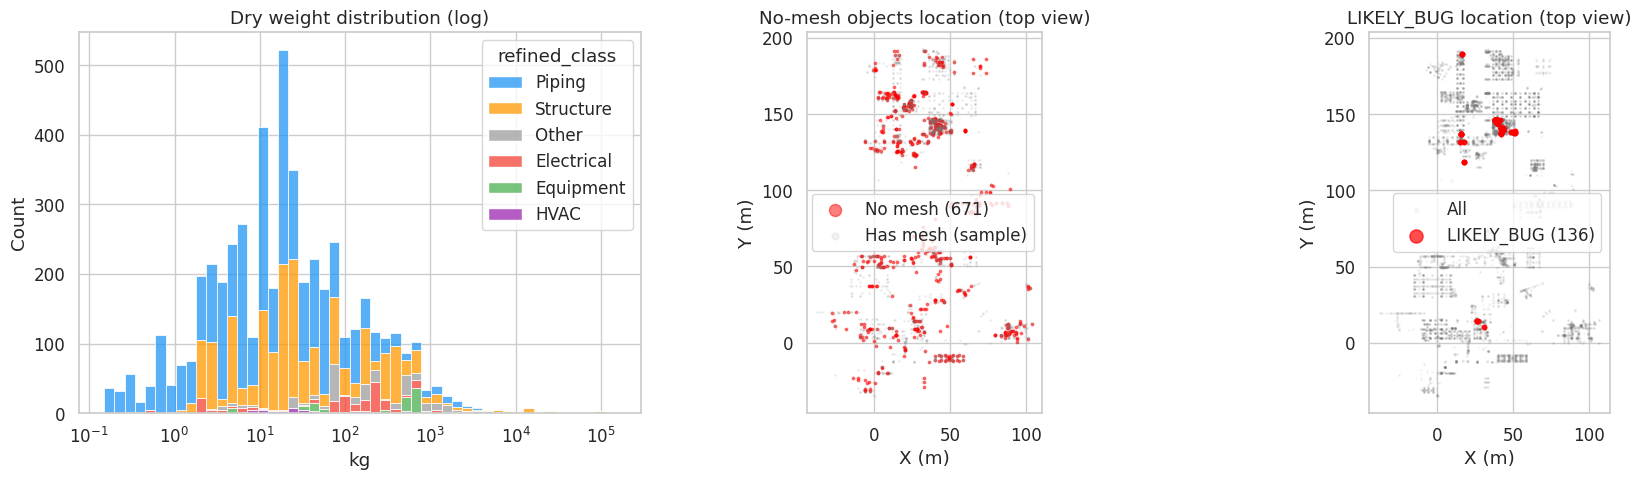

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7d. Weight distribution by class (log)
w_data = gold[gold["dry_weight_kg"] > 0].copy()
sns.histplot(data=w_data, x="dry_weight_kg", hue="refined_class",
             hue_order=class_order, palette=palette, bins=50,
             ax=axes[0], multiple="stack", log_scale=True)
axes[0].set_title("Dry weight distribution (log)")
axes[0].set_xlabel("kg")

# 7e. No-mesh objects in 3D space
no_mesh_phys = no_mesh[(no_mesh["is_container"] == False) & (no_mesh["is_analysis_volume"] == False)]
axes[1].scatter(no_mesh_phys["centroid_x"], no_mesh_phys["centroid_y"],
                s=3, alpha=0.5, c="red", label=f"No mesh ({len(no_mesh_phys)})")
with_mesh_sample = with_mesh.sample(min(2000, len(with_mesh)), random_state=42)
axes[1].scatter(with_mesh_sample["centroid_x"], with_mesh_sample["centroid_y"],
                s=1, alpha=0.1, c="gray", label="Has mesh (sample)")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")
axes[1].set_title("No-mesh objects location (top view)")
axes[1].legend(markerscale=5)
axes[1].set_aspect("equal")

# 7f. LIKELY_BUG in 3D space
axes[2].scatter(gold["centroid_x"], gold["centroid_y"],
                s=1, alpha=0.05, c="gray", label="All")
axes[2].scatter(bugs["centroid_x"], bugs["centroid_y"],
                s=10, alpha=0.7, c="red", label=f"LIKELY_BUG ({len(bugs)})")
axes[2].set_xlabel("X (m)")
axes[2].set_ylabel("Y (m)")
axes[2].set_title("LIKELY_BUG location (top view)")
axes[2].legend(markerscale=3)
axes[2].set_aspect("equal")

plt.tight_layout()
plt.savefig(FIGURES / "01_s7_quality_suspects.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: 품질 의심 영역

- Weight 분포: log scale 에서 클래스별 무게 범위 차이가 큼. 극단적 이상치는 데이터 오류 가능성
- No-mesh 위치: 빨간 점이 특정 영역에 몰려있으면 → 그 영역의 모델링이 불완전한 것
- LIKELY_BUG 위치: 136개 의심 객체의 공간 분포 → 특정 영역에 집중되면 시스템적 분류 오류

> 세 차트 모두 "이 영역/클래스의 데이터를 신뢰할 수 있는가" 에 대한 근거를 제공

## 8. 자유 탐색 공간

여기서부터는 위에서 발견한 것을 기반으로 자유롭게 파고들 수 있습니다. 예시:

```python
# 특정 파이프라인의 모든 객체 보기
gold[gold["sp3d_pipeline"] == "P-10147"][["display_name", "dry_weight_kg", "length_m"]]

# 특정 객체의 이웃 찾기
obj_id = "여기에_object_id"
neighbors = adj[adj["source_object_id"] == obj_id]["target_object_id"]
gold[gold["object_id"].isin(neighbors)]

# SPARQL 로 OWL 에 직접 질의
from rdflib import Graph as RDFGraph
g = RDFGraph()
g.parse(str(config.ONTOLOGY_OWL_DIR / "bim-ontology.owl"))
g.parse(str(config.ONTOLOGY_OWL_DIR / "bim-objects.ttl"))
result = g.query("SELECT ?name WHERE { ?s a bim:ProcessEquipment ; bim:displayName ?name }")
```

In [10]:
# 여기에 자유롭게 코드를 추가하세요
